# Explore here

--- API Extraction Summary ---
Successfully downloaded 200 total task records from the live API.

--- Raw Dataframe Head (First 5 rows) ---


,userId,id,title,completed
0,1,1,delectus aut autem,False
1,1,2,quis ut nam facilis et officia qui,False
2,1,3,fugiat veniam minus,False
3,1,4,et porro tempora,True
4,1,5,laboriosam mollitia et enim quasi adipisci qui...,False



--- Dataset Summary Statistics ---


,userId,id,title,completed
count,200.000000,200.000000,200,200
unique,NaN,NaN,200,2
top,NaN,NaN,delectus aut autem,False
freq,NaN,NaN,1,110
mean,5.500000,100.500000,NaN,NaN
std,2.879489,57.879185,NaN,NaN
min,1.000000,1.000000,NaN,NaN
25%,3.000000,50.750000,NaN,NaN
50%,5.500000,100.500000,NaN,NaN
75%,8.000000,150.250000,NaN,NaN



--- Generated Visualization ---


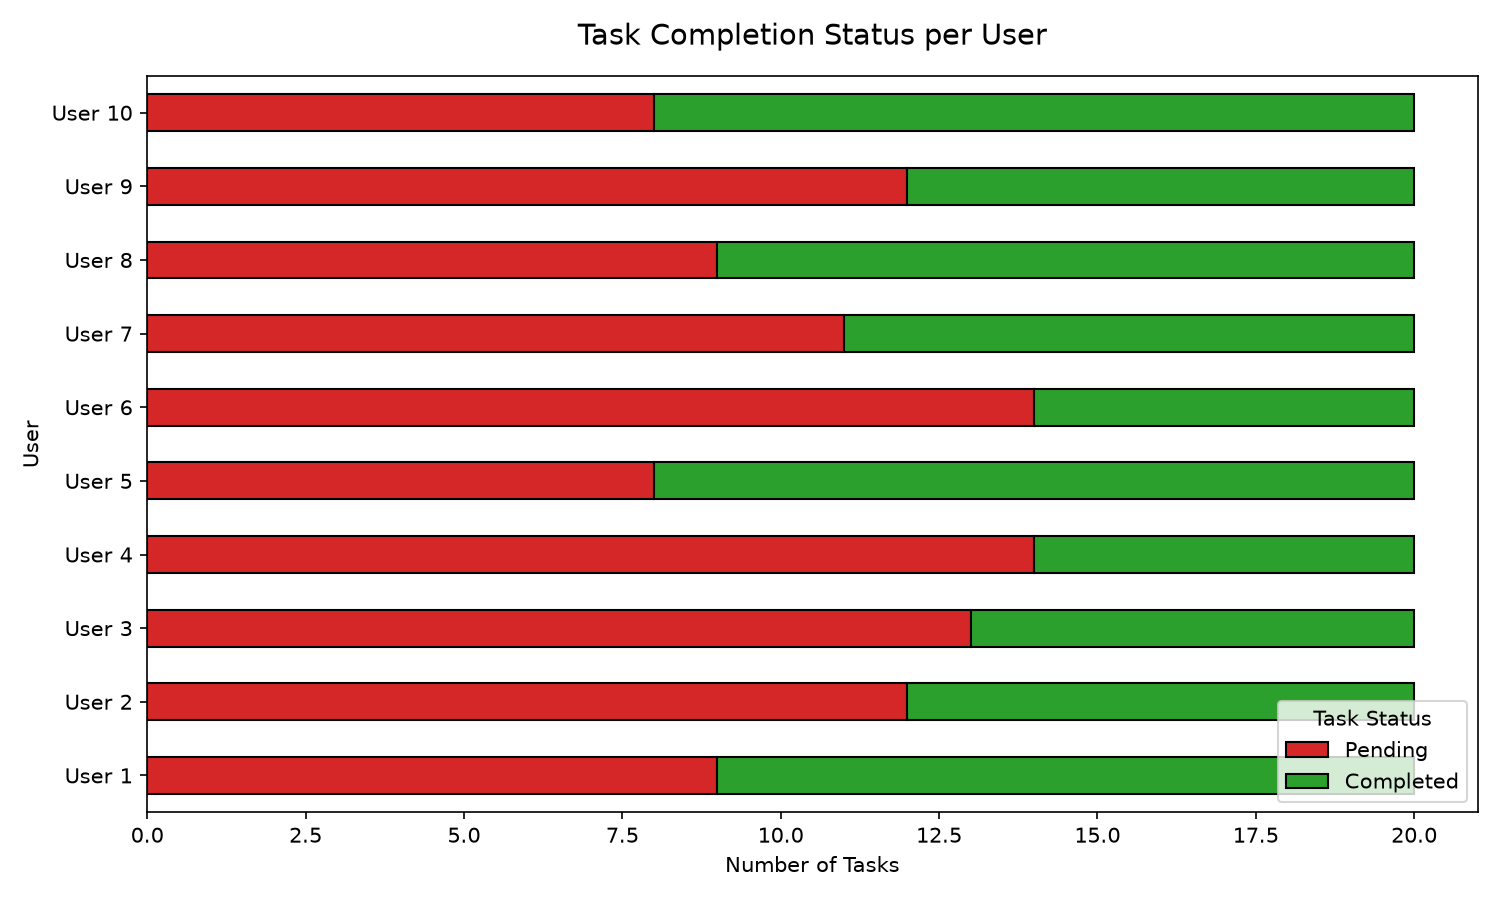


Process completed successfully: Data written to 'project_data.db' and database connection closed.


In [22]:
import sqlite3
import pandas as pd
import requests
import matplotlib.pyplot as plt
from IPython.display import Image, display

# 1. Retrieve data from the Todos API endpoint
url = "https://jsonplaceholder.typicode.com/todos"
response = requests.get(url)

# Check if the API request was successful
if response.status_code == 200:
    api_data = response.json()
    
    print(f"--- API Extraction Summary ---")
    print(f"Successfully downloaded {len(api_data)} total task records from the live API.")
    
    # 2. Parse the raw JSON into a Pandas DataFrame
    df = pd.DataFrame(api_data)
    
    # 3. Explicitly display raw data insights in the notebook
    print("\n--- Raw Dataframe Head (First 5 rows) ---")
    display(df.head(5)) # Renders a clean, interactive HTML table in Jupyter
    
    print("\n--- Dataset Summary Statistics ---")
    display(df.describe(include='all')) # Displays descriptive stats for numeric and categorical columns
    
    # 4. Prepare data for visualization: Group by userId and completed status
    task_breakdown = df.groupby(['userId', 'completed']).size().unstack(fill_value=0)
    
    # Rename columns for clarity (False = Pending, True = Completed)
    task_breakdown = task_breakdown.rename(columns={False: 'Pending', True: 'Completed'})
    
    # Calculate total tasks per user and sort ascending to make the chart ladder properly
    task_breakdown['Total'] = task_breakdown['Pending'] + task_breakdown['Completed']
    task_breakdown = task_breakdown.sort_values('Total', ascending=True)
    
    # Drop the temporary Total column so it doesn't get plotted as a stack segment
    task_breakdown = task_breakdown.drop(columns=['Total'])
    
    # Create clean user-friendly index labels
    task_breakdown.index = 'User ' + task_breakdown.index.astype(str)
    
    # 5. Create a stacked horizontal bar chart
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot stacked bars (Red for Pending, Green for Completed)
    task_breakdown.plot(kind='barh', stacked=True, color=['#d62728', '#2ca02c'], edgecolor='black', ax=ax)
    
    plt.xlabel('Number of Tasks')
    plt.ylabel('User')
    plt.title('Task Completion Status per User', pad=15, fontsize=14)
    plt.legend(title='Task Status', loc='lower right')
    
    # Ensure all labels fit neatly and are not truncated
    plt.tight_layout()
    
    # Save the plot to an image file
    plot_filename = 'tasks_breakdown_per_user.png'
    plt.savefig(plot_filename, dpi=150)
    plt.close()
    
    print("\n--- Generated Visualization ---")
    
    # Display the saved image inline in the Jupyter Notebook cell output
    display(Image(filename=plot_filename))

    # 6. Save the parsed data to an SQL database (SQLite)
    conn = sqlite3.connect("project_data.db")
    df.to_sql("todos", conn, if_exists="replace", index=False)
    conn.close()
    
    print("\nProcess completed successfully: Data written to 'project_data.db' and database connection closed.")
else:
    print(f"Failed to retrieve data from API: {response.status_code}")